# Desafío 3 - Predicción de churn

## 1. Introducción

En el presente análisis se aborda la predicción de fuga de clientes (*churn*) en una empresa de telecomunicaciones utilizando técnicas de aprendizaje supervisado.

El objetivo es construir modelos capaces de clasificar a los clientes como **fugados** o **no fugados**, a partir de variables relacionadas con permanencia, servicios contratados, facturación y método de pago.

Siguiendo la lógica del notebook anterior, el desarrollo se organiza en etapas: carga de datos, análisis de calidad, limpieza, análisis exploratorio, preprocesamiento, partición de datos, entrenamiento de modelos, optimización de hiperparámetros, evaluación y conclusiones.

## 2. Objetivo del análisis

El objetivo de este análisis es desarrollar un modelo predictivo que permita estimar la probabilidad de fuga de clientes, con el fin de identificar tempranamente a quienes presentan mayor riesgo de abandonar la compañía.

De esta forma, la empresa podría enfocar sus estrategias de retención en los clientes más vulnerables, mejorando la fidelización y reduciendo pérdidas de ingresos.

# 3. Librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")## ignorar avisos de flags poco importantes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 4. Carga de datos

Se carga la base de datos entregada para realizar el análisis exploratorio, la limpieza y el posterior entrenamiento de modelos de clasificación.

In [2]:
df = pd.read_excel("Telco-Customer-Churn.xlsx")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 5. Análisis de calidad de datos

En esta etapa se revisa la estructura de la base, los tipos de datos, los valores faltantes, duplicados y la distribución de la variable objetivo.

Este análisis es importante porque cualquier inconsistencia puede afectar directamente el entrenamiento y la evaluación de los modelos predictivos.

In [6]:
df.describe(include="all").T ##incluimos a las variables que no son int

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.isnull().sum().sort_values(ascending=False) ##revisamos que no hayan vacios en los campos

TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

In [9]:
df.duplicated().sum() ## revisamos que no hayan duplicados

np.int64(0)

In [11]:
df["Churn"].value_counts() #contamos los churns

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df["Churn"].value_counts(normalize=True).round(4) * 100 #sacamos el porcentaje de cada uno.

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

### Observaciones

- La base contiene variables numéricas y categóricas, por lo que será necesario aplicar transformaciones distintas a cada tipo de dato.
- La variable objetivo (**Churn**) presenta desbalance, ya que la cantidad de clientes que no abandonan es mayor a la de quienes sí abandonan.
- La columna `customerID` funciona solo como identificador, por lo que no aporta valor predictivo directo al modelo.
- La variable `TotalCharges` debe validarse como numérica para asegurar consistencia en el preprocesamiento.

## 6. Limpieza de datos

Para el proceso de modelado se realizarán ajustes básicos de limpieza:

- Conversión segura de `TotalCharges` a formato numérico.
- Eliminación de duplicados si existieran.
- Eliminación de la columna identificadora `customerID`, ya que no entrega información útil para predecir churn.

In [17]:
df_clean = df.copy()

df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")#coerce lo que hace es que si encuentra un valor invalido lo comvierte en NaN
df_clean = df_clean.drop_duplicates() #botamos los valores duplicados de la df
df_clean = df_clean.drop(columns=["customerID"]) #botamos columna CostumerID

df_clean.shape

(7043, 20)

In [15]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
df_clean.isnull().sum().sort_values(ascending=False) #volvemos a botar los NaN

TotalCharges        11
gender               0
Partner              0
SeniorCitizen        0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

Luego de la limpieza, la base queda preparada para el análisis predictivo. Se conserva la mayor parte de la información original, eliminando únicamente el identificador del cliente y asegurando que las variables numéricas estén correctamente tipadas.

## 7. Análisis exploratorio de datos

A continuación, se analiza la distribución de las variables numéricas y algunas relaciones clave con la variable objetivo. Esto permite comprender mejor qué patrones podrían estar asociados a la fuga de clientes.

In [20]:
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist() #Columnas que sean de tipo numerica
cat_cols = df_clean.select_dtypes(include="object").columns.tolist() #Columnas que sean de tipo categorica (texto)

num_cols, cat_cols[:5]

(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines'])

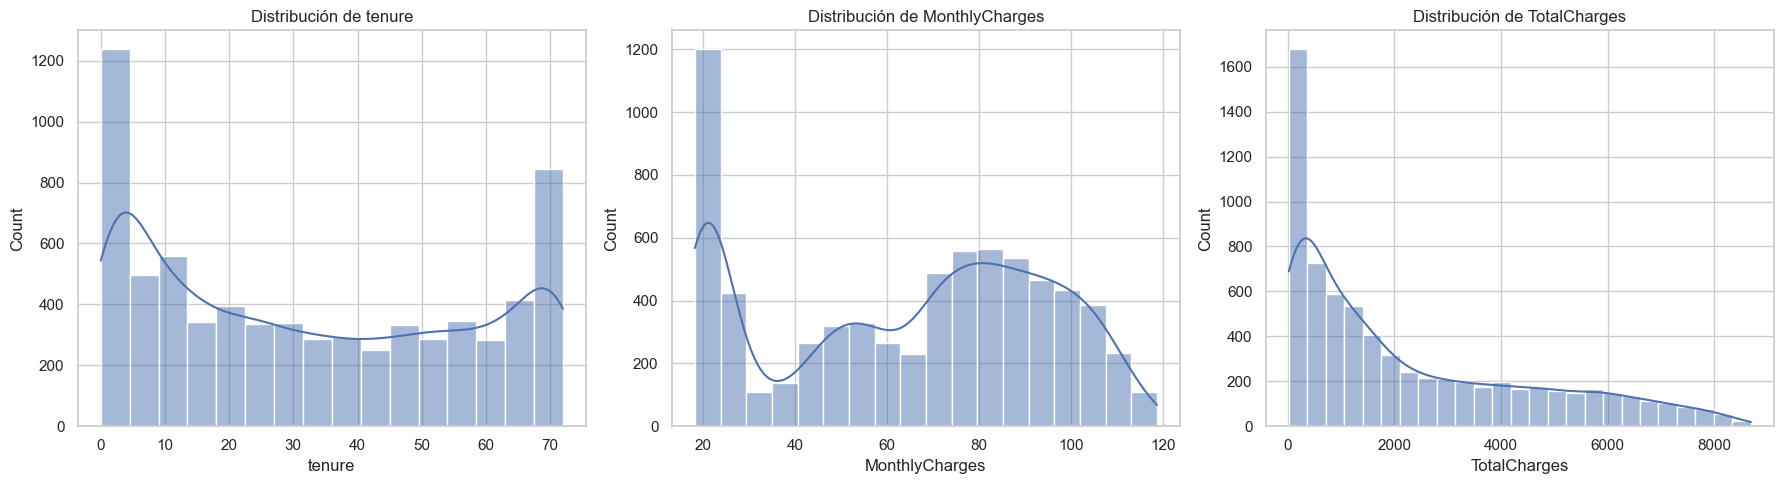

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(df_clean[col], kde=True, ax=ax)
    ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

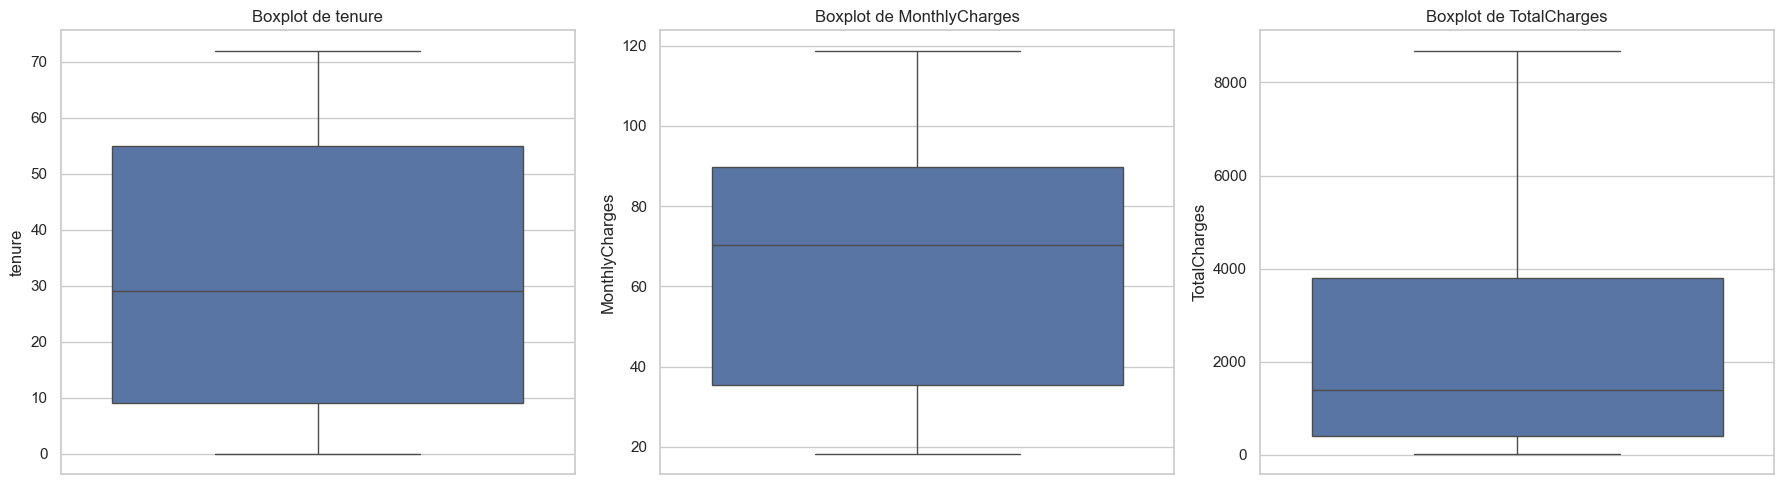

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(data=df_clean, y=col, ax=ax)
    ax.set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

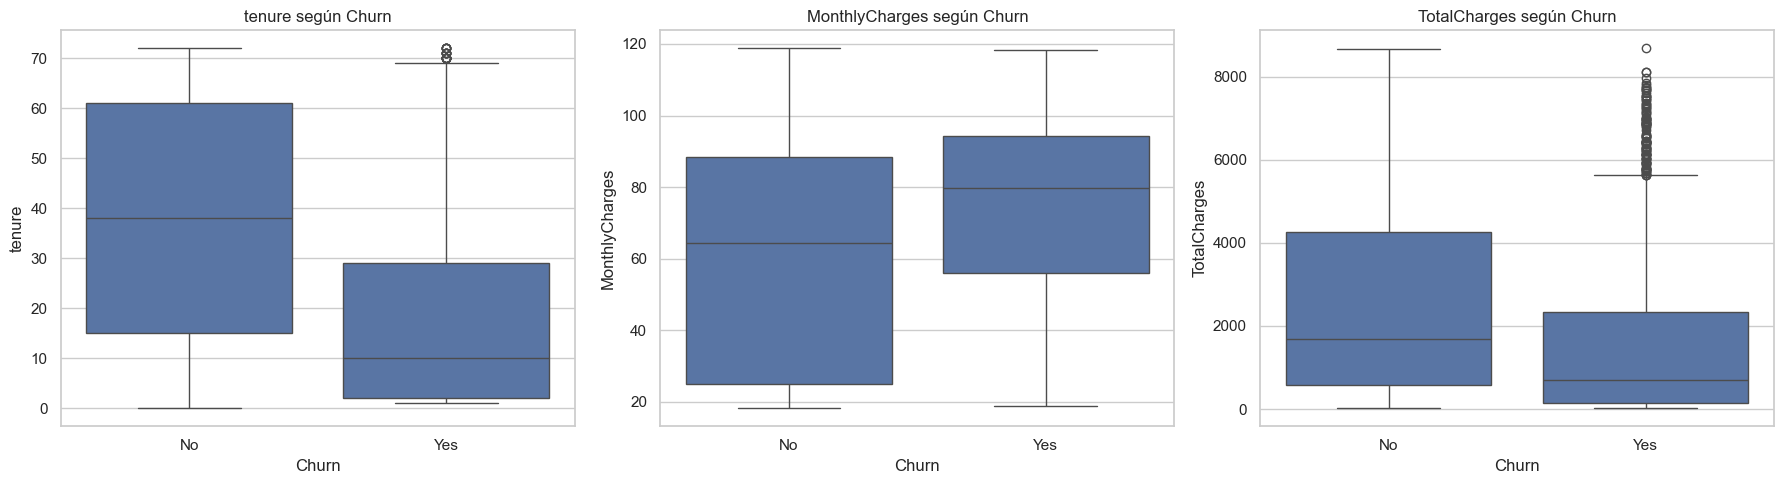

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(data=df_clean, x="Churn", y=col, ax=ax)
    ax.set_title(f"{col} según Churn")

plt.tight_layout()
plt.show()

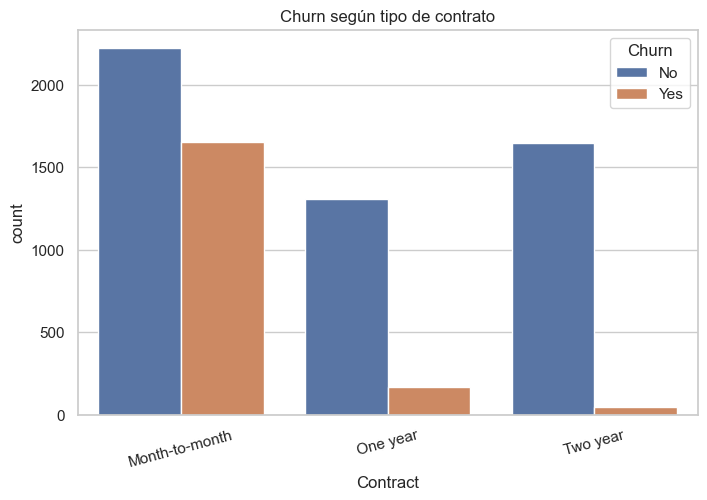

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="Contract", hue="Churn")
plt.title("Churn según tipo de contrato")
plt.xticks(rotation=15)
plt.show()

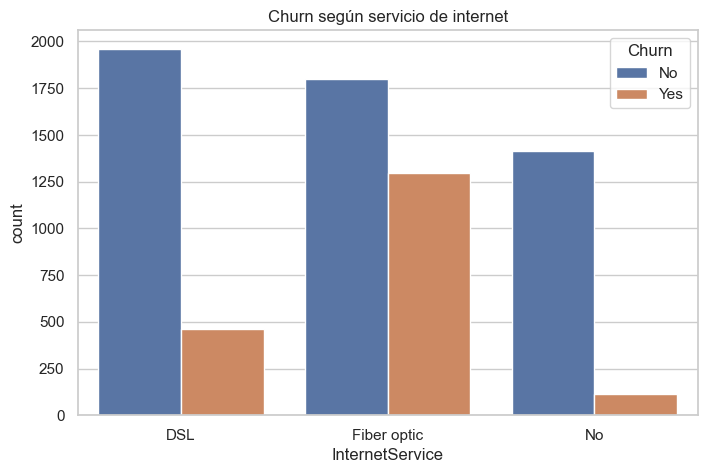

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="InternetService", hue="Churn")
plt.title("Churn según servicio de internet")
plt.show()

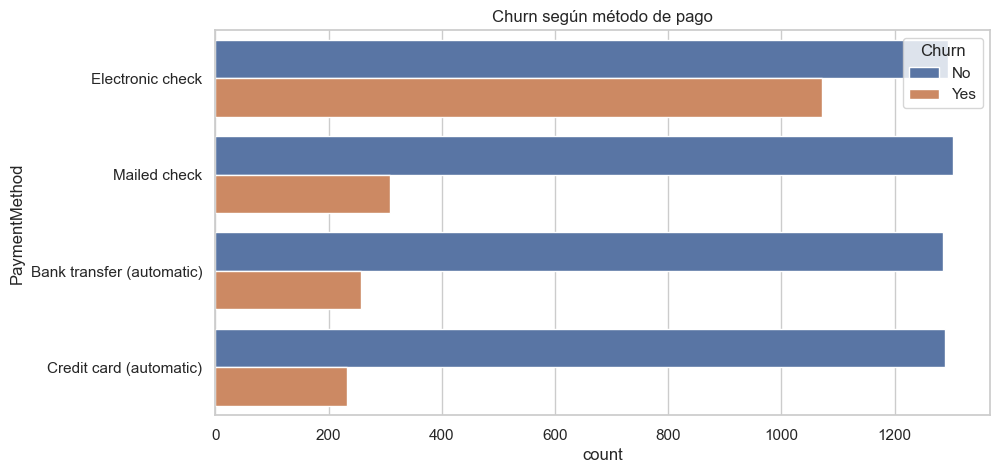

In [26]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, y="PaymentMethod", hue="Churn")
plt.title("Churn según método de pago")
plt.show()

### Observaciones

- La permanencia (`tenure`) muestra una relación importante con churn: clientes con menor antigüedad tienden a abandonar más.
- Los contratos **Month-to-month** presentan una mayor proporción de fuga que los contratos de mayor plazo.
- Los cargos mensuales altos aparecen con más frecuencia entre clientes que abandonan.
- Algunos servicios y métodos de pago, como **Fiber optic** y **Electronic check**, parecen concentrar más casos de churn.

## 8. Preparación de variables

Se separará la variable objetivo y luego se dividirán los datos en entrenamiento y prueba.

Además, se construirá un preprocesador con dos flujos:

- **Variables numéricas**: imputación de nulos y escalado.
- **Variables categóricas**: imputación de nulos y codificación One Hot.

Este enfoque permite incorporar todo el preprocesamiento dentro de un pipeline, evitando fugas de información entre entrenamiento y prueba.

In [27]:
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 19)
X_test : (1409, 19)
y_train: (5634,)
y_test : (1409,)


In [28]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()) ##creamos un transformador de numeros para que la magnitud de los valores disminuya
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), ##reemplazamos los nulos o valores menos frecuentes por los mas frecuentes
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  #transformamos la variable categorica en numerica e ignoramos las que no se conozcan.
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols), #a las variables numericas se le aplica numeric_transformer
    ("cat", categorical_transformer, cat_cols) #a las variables categoricas se les aplica categorical_transformer.
])

num_cols, cat_cols

(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

### Observaciones

Se utilizó una partición estratificada para conservar la proporción de churn en entrenamiento y prueba. Esto es especialmente importante cuando la variable objetivo está desbalanceada.

## 9. Entrenamiento de modelos y optimización de hiperparámetros

Se entrenarán tres algoritmos de clasificación:

1. **Regresión logística**
2. **Árbol de decisión**
3. **Random Forest**

Cada modelo será ajustado mediante `GridSearchCV`, utilizando **F1-score** como métrica principal de optimización, ya que en este problema interesa equilibrar precisión y recall.

In [29]:
modelos = {
    "Regresión Logística": {
        "modelo": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"]
        }
    },
    "Árbol de Decisión": {
        "modelo": DecisionTreeClassifier(class_weight="balanced", random_state=42),
        "params": {
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 10],
            "model__min_samples_leaf": [1, 4]
        }
    },
    "Random Forest": {
        "modelo": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [8, None],
            "model__min_samples_leaf": [1, 2]
        }
    }
}

In [30]:
resultados = []
mejores_modelos = {}

for nombre, config in modelos.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", config["modelo"])
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=config["params"],
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    mejores_modelos[nombre] = grid.best_estimator_

    y_pred = grid.predict(X_test)
    y_prob = grid.predict_proba(X_test)[:, 1]

    resultados.append({
        "Modelo": nombre,
        "Mejores parámetros": grid.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="F1", ascending=False)
resultados_df

,Modelo,Mejores parámetros,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,"{'model__max_depth': 8, 'model__min_samples_le...",0.755145,0.526508,0.770053,0.625407,0.841631
1,Árbol de Decisión,"{'model__max_depth': 5, 'model__min_samples_le...",0.755145,0.526902,0.759358,0.622125,0.832279
0,Regresión Logística,"{'model__C': 0.1, 'model__solver': 'lbfgs'}",0.742370,0.509532,0.786096,0.618297,0.840859


## 10. Evaluación de modelos

Se comparan los modelos usando métricas pertinentes para clasificación:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**

Dado que el problema busca identificar clientes con riesgo de fuga, el **recall** y el **F1-score** toman especial relevancia, ya que interesa detectar la mayor cantidad posible de clientes propensos a abandonar sin disparar excesivamente los falsos positivos.

In [32]:
resultados_df[["Modelo", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]].round(4)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,0.7551,0.5265,0.7701,0.6254,0.8416
1,Árbol de Decisión,0.7551,0.5269,0.7594,0.6221,0.8323
0,Regresión Logística,0.7424,0.5095,0.7861,0.6183,0.8409


In [33]:
mejor_modelo_nombre = resultados_df.iloc[0]["Modelo"]
mejor_modelo = mejores_modelos[mejor_modelo_nombre]

print("Mejor modelo según F1-score:", mejor_modelo_nombre)

Mejor modelo según F1-score: Random Forest


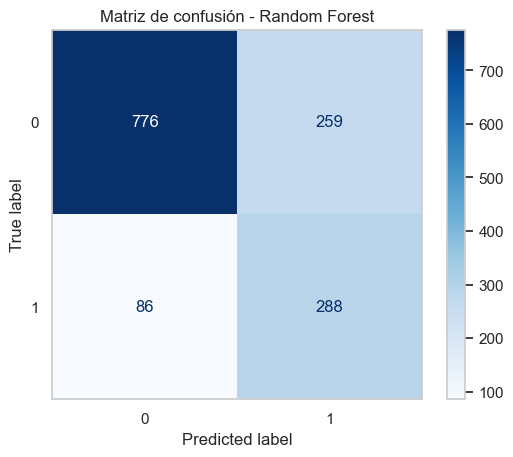

In [34]:
y_pred_best = mejor_modelo.predict(X_test)
y_prob_best = mejor_modelo.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Matriz de confusión - {mejor_modelo_nombre}")
plt.grid(False)
plt.show()

In [35]:
print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



### Observaciones

En este caso, el mejor modelo se selecciona según el mayor **F1-score**, ya que entrega un equilibrio razonable entre detectar churn y no sobredimensionar demasiado las alertas.

No necesariamente el modelo con mayor accuracy será el más útil, porque una base desbalanceada puede inflar esa métrica sin capturar bien a los clientes que realmente abandonan.

## 11. Importancia de variables del mejor modelo

Para complementar la interpretación, se revisan las variables más influyentes del mejor modelo. Esto permite identificar qué factores están más asociados a la fuga de clientes.

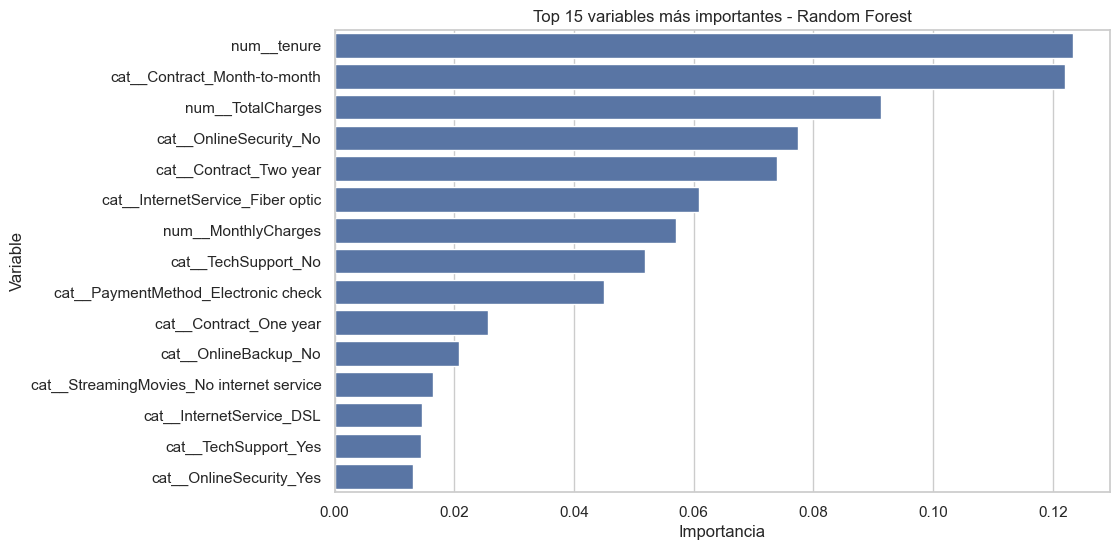

In [36]:
if mejor_modelo_nombre == "Random Forest":
    feature_names = mejor_modelo.named_steps["preprocessor"].get_feature_names_out()
    importancias = mejor_modelo.named_steps["model"].feature_importances_

    importancia_df = (
        pd.DataFrame({
            "Variable": feature_names,
            "Importancia": importancias
        })
        .sort_values(by="Importancia", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importancia_df, x="Importancia", y="Variable")
    plt.title("Top 15 variables más importantes - Random Forest")
    plt.show()

    importancia_df
else:
    print("La importancia de variables se presenta directamente si el mejor modelo es Random Forest.")

## 12. Conclusiones

A partir del análisis realizado, se logra construir un modelo capaz de predecir la fuga de clientes con un desempeño razonable, destacando especialmente en métricas como recall, F1 y ROC-AUC.

En términos de negocio, los principales hallazgos apuntan a que el churn se relaciona fuertemente con variables como:

- baja antigüedad del cliente (`tenure`),
- contratos mensuales,
- altos cargos mensuales,
- uso de fibra óptica,
- ausencia de servicios de soporte o seguridad,
- ciertos métodos de pago, como `Electronic check`.

Estos patrones son valiosos porque permiten focalizar campañas de retención en segmentos más expuestos al abandono.

## 13. Recomendaciones finales

Como siguiente paso, la empresa podría:

- priorizar clientes con contrato **Month-to-month** y baja antigüedad,
- ofrecer mejoras o beneficios a clientes con alta probabilidad de churn,
- reforzar servicios de soporte y seguridad,
- complementar este análisis con modelos más avanzados o calibración de umbrales de decisión.

En resumen, el ejercicio demuestra cómo las técnicas de machine learning pueden transformarse en una herramienta concreta para apoyar decisiones de retención de clientes.